In [ ]:
if r_inc_z != 0 and r_inc_x == 0:
        p1 = np.array([hit_point[0], limit_y_negative, hit_point[2]])
        p2 = np.array([hit_point[0], limit_y_positive, hit_point[2]])
        list_point.append(p1)
        list_point.append(p2)
        return list_point
    if r_inc_z != 0 and r_inc_x != 0:
        p1 = np.array([origin[0], origin[1], hit_point[2]])
        #print(hit_point, origin , 'puntos LN')
        #print(r_inc_x, r_inc_y, ' r_inc LN')
        arcotan_radians = math.atan(r_inc_x/r_inc_y)
        arcotan_degress = math.degrees(arcotan_radians)
        print('------------------------------------')
        print(arcotan_degress, 'arcotan_degress LN')
        for x in np.arange(0.0, float(5), 0.1):
            for y in np.arange(0.0, float(5), 0.1):
                if y != 0.0:
                    arcotan_radias_theta_experimental = math.atan(x/y)
                    arcotan_degress_theta_experimental = math.degrees(arcotan_radias_theta_experimental)
                    #print(arcotan_degress_theta_experimental == arcotan_degress, x, y, 'arcotan_degress_theta_experimental')
                    if arcotan_degress_theta_experimental == arcotan_degress and (y >= hit_point[1] and y <= hit_point[1] + 2.5) and ( x >= hit_point[0] and  x <= hit_point[0] + 2.5):
                        coord_x.append(x)
                        coord_y.append(y)
                        print(arcotan_degress_theta_experimental, 'arcotan_degress_theta_experimental LN')
                        print(x,y, 'x,y LN')
                        print('------------------------------------')
        print(coord_x, 'coord_x')
        print(coord_y, 'coord_y')
        if len(coord_x) != 0 and len(coord_y) != 0:
            p2 = np.array([3, 3, hit_point[2]])
            list_point.append(p1)
            list_point.append(p2)
            return list_point

In [6]:
import numpy as np
import plotly.graph_objects as go
import math

a_and_p = int(input('Escribe "0" para ángulo de incidencia o "1" para punto de inicio'))


def reflect(I, n, calculate_angle_theta_1, hit_point, limit_x_positive, origin, LN):

    if hit_point[1]-origin[1] == 0:
        return [hit_point[0], hit_point[1], hit_point[1]]
        
    if hit_point[2]-origin[2] == 0:
         return [origin[0], origin[1], origin[2]]
        
    v_inc = [ hit_point[0]-origin[0], hit_point[1]-origin[1], hit_point[2]-origin[2] ]
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z != 0 and r_inc_x == 0:

        #module = math.sqrt((hit_point[0])**2 + (hit_point[1])**2 + (hit_point[2])**2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        theta_2 = math.degrees(angulo_radianes)
        # Distancia en y
        y = r_inc_y
        #Coordenada en z
        
        z = r_inc_y * math.sin(angulo_radianes)

        if(r_inc_y * math.sin(angulo_radianes) == LN[0][2] - origin[2] ):
            z = r_inc_y * math.sin(angulo_radianes)
        else:
            z = LN[0][2] - origin[2]
        
        return [origin[0], origin[1], LN[0][2] + z]
    if r_inc_z != 0 and r_inc_x != 0:
        angulo_radianes = math.radians(calculate_angle_theta_1)
        #Distancia en x 
        x = r_inc_x
        # Distanciaen y
        y = r_inc_y
        #hipotenusa en x and y
        hipo_xy = math.sqrt((r_inc_x**2) + (r_inc_y**2))
        
        #coordenada en z 
        f_xy =  hipo_xy/math.cos(angulo_radianes)

        if(f_xy * math.sin(angulo_radianes) == LN[0][2] - origin[2] ):
            z = f_xy * math.sin(angulo_radianes)
        else:
            z = LN[0][2] - origin[2]
        #print(x, 'x')
        #print(y, 'y')
        #print(z, 'zyes
        return [origin[0], origin[1], LN[0][2] + z]

def calculate_angle(u, v):
    

    w = [L_N[1][0]-L_N[0][0], L_N[1][1]-L_N[0][1], L_N[1][2]-L_N[0][2]]
    dot_product = np.dot(u, w)

    # Magnitudes
    norm_u = np.linalg.norm(u)
    norm_w = np.linalg.norm(w)

    # Ángulo
    
    theta_rad = math.acos(dot_product / (norm_u * norm_w))
    theta_deg = math.degrees(theta_rad)
    return theta_deg

def find_two_numbers_for_theta(theta_deg, step=0.1, limit=5, tol=0.01):
    angles_example = [
        {
            'angle': 0,
            'x': 0,
            'y': 2.5,
        },
        {
            'angle': 10,
            'x': 0,
            'y': 2.14,
        },
        {
            'angle': 20,
            'x': 0,
            'y': 1.75,
        },
        {
            'angle': 30,
            'x': 0,
            'y': 1.33,
        },
        {
            'angle': 40,
            'x': 0,
            'y': 0.81,
        },
        {
            'angle' : 50,
            'x' : 0,
            'y' : 0.1,
        },
        {
            'angle' : 50,
            'x' : 0,
            'y' : 0.1,
        },
        {
            'angle' : 60,
            'x' : 0.56,
            'y' : 0,
        },
        {
            'angle' : 70,
            'x' : 1.09,
            'y' : 0,
        },
        {
            'angle' : 80,
            'x' : 1.56,
            'y' : 0,
        },
        {
            'angle': 90,
            'x': 2,
            'y': 0,
        },
    ]
    
    resultados = []
    for x in angles_example:
        if x['angle'] == theta_deg:
            resultados.append(x)
    return resultados

def calculate_angle_theta_1(p1 , p2, LN, angle):
    
    if angle >= 0 and angle <= 90:
        #Plano ZY
        resultados = find_two_numbers_for_theta(angle)
        x = 1.5
        y = resultados[0]['x']
        z = resultados[0]['y']
        return angle, [x,y,z]
        
    if hit_point[1]-origin[1] == 0:
        return 90
    if hit_point[2]-origin[2] == 0:
        return 0
    
    v_inc = [ p2[0]-p1[0], p2[1]-p1[1], p2[2]-p1[2] ]

    r_inc_z = p2[2]-p1[2]
    r_inc_y = p2[1]-p1[1]
    r_inc_x = p2[0]-p1[0]

    #theta = calculate_angle(v_inc, LN)
    #print(theta, 'calculate_angle')

    if r_inc_z != 0 and r_inc_x == 0:

        #Plano ZY
        #f_xy = math.sqrt( ( r_inc_y )**2 + ( r_inc_z )**2 )
        #r_in_z = f_xy*cos(Theta)
        theta_radians = math.atan( r_inc_y / r_inc_z )
        theta_degress = math.degrees(theta_radians)
        theta = 180 - 90 - theta_degress
        ##print(theta, 'theta')
        #print(theta_1, 'theta 1 Entro a r_inc_z != 0 and r_inc_x == 0')
        return theta
    
    if r_inc_z != 0 and r_inc_x != 0:
        ##catetoAdyacente
        ady = LN[0][2]-p1[2]
        #catetoOpuesto
        hip_r_inc_x_y  = math.sqrt( ( r_inc_x )**2 + ( r_inc_y )**2 )
        #Angulo 
        arcotan_radians = math.atan(hip_r_inc_x_y/ady)
        arcotan_degress = math.degrees(arcotan_radians)
        #print(arcotan_degress, 'arcotan_degress')
        ## theta 1
        theta = 180 - 90 - arcotan_degress
        #print(theta, 'theta')
        #print(theta, 'theta 1 Entro r_inc_z != 0 and r_inc_x != 0')
        return theta


def linea_normal(origin, hit_point, limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, angulo_incidente):

    if angulo_incidente == 90:
        r_inc_z = 1.5
        r_inc_y = 0
        r_inc_x = 1.5
        list_point = []
        p1 = [r_inc_x, r_inc_y, r_inc_z ]
        p2 = [r_inc_x , r_inc_y + 5,  r_inc_z]
        list_point.append(p1)
        list_point.append(p2)
        return list_point
    
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]
    list_point = []
    p1 = [r_inc_x*0 + origin[0], r_inc_y*0 + origin[1], hit_point[2]]
    p2 = [r_inc_x*2 + origin[0], r_inc_y*2 + origin[1], hit_point[2]]
    #print(p1, 'p1')
    #print(p2, 'p2')
    list_point.append(p1)
    list_point.append(p2)
    return list_point
    
def refract(I, n, n1, n2, calculate_angle_theta_1, hit_point, origin, y2):
    
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z == 0:
        if r_inc_x == 0:
                return [0, y2  - hit_point[1] , 0], False, 0
        if r_inc_x != 0:
            ##(coordenada en y)
            coord_y = y2 - hit_point[1]
            ##Plano XY (coordenada en x)
            alpha = math.atan(r_inc_x/r_inc_y)
            f_xy = coord_y/math.cos(alpha)
            coord_x = f_xy * math.sin(alpha) 
            return [coord_x, y2 - hit_point[1], 0], False, 0
    if r_inc_z != 0 and r_inc_x == 0:
        #Ley de snell
        #n_1*sen(0_1) = n_2*sen(0_2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        seno_value = math.sin(angulo_radianes)
    
        rho = (n1 * seno_value)/n2
        sin_radians = math.asin(rho)
        theta_3 = math.degrees(sin_radians)
        theta_3_radians = theta_3 * (math.pi/180)
    
        coord_fx = y2 - y1
        module_f = coord_fx/(math.cos(theta_3_radians))
        fy = module_f*math.sin(theta_3_radians)
        fy_pitagoras = math.sqrt( (module_f)**2 - (coord_fx)**2)
        return [0, coord_fx, fy ], False, theta_3
    if r_inc_z != 0 and r_inc_x != 0:                
            
        #Ley de snell
        #n_1*sen(0_1) = n_2*sen(0_2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        seno_value = math.sin(angulo_radianes)
        rho = (n1 * seno_value)/n2
        sin_radians = math.asin(rho)
        theta_3 = math.degrees(sin_radians)
        theta_3_radians = theta_3 * (math.pi/180)
        
        ##(coordenada en y)
        coord_y = y2 - hit_point[1]
        ##Plano XY (coordenada en x)
        alpha = math.atan(r_inc_x/r_inc_y)
        f_xy = coord_y/math.cos(alpha)
        coord_x = f_xy * math.sin(alpha) 
        ##Plano ZX (coordenada en z)
        if (origin[0] > hit_point[0]):
            f_zx = ((-1)*coord_x)/math.cos(theta_3_radians)
        else:
            f_zx = coord_x/math.cos(theta_3_radians)
        coord_z = f_zx * math.sin(theta_3_radians)
        return [coord_x , coord_y,  coord_z  ], False, theta_3
        
def second_refract(point, n1, n2, calculate_angle_theta_1, limit_x_positive, limit_y_positive, limit_z_positive, theta_3, origin, hit_point, SLN):
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z == 0:
        if r_inc_x == 0:
            if hit_point[2]-origin[2] == 0:
                return [ [point[0], point[0]], [point[1],  SLN[1][1] ], [point[2], SLN[1][2]] ], 0
        if r_inc_x != 0:
            return [ [  point[0],  SLN[1][0] ], [point[1],  SLN[1][1] ], [point[2], SLN[1][2]] ], 0
    if r_inc_z != 0 and r_inc_x == 0:
        
        alpha = 180 - 90 - ( 90 - theta_3)
        angulo_radianes = math.radians(alpha)
        seno_value = math.sin(angulo_radianes)
        rho = (n2 * seno_value)/n1
        sin_radians = math.asin(rho)
        theta_4 = math.degrees(sin_radians)

        z = limit_z_positive * math.sin(sin_radians)
        y = limit_y_positive * math.cos(sin_radians)
        return [ [point[0], point[0]], [point[1],  point[1] + y], [point[2], point[2]+z]], theta_4
    if r_inc_z != 0 and r_inc_x != 0:
    
        w = [SLN[1][0] - point[0], SLN[1][1] - point[1], SLN[1][2] - point[2]]
        alpha_xy = math.atan(r_inc_x/r_inc_y)
        #coordenada en x
        x = w[0]
        #coordenada en y
        f_xy = x/math.sin(alpha_xy)
        y = f_xy * math.cos(alpha_xy)
        #coordenada en z
        alpha = 180 - 90 - ( 90 - theta_3)
        #print(alpha,'alpha')
        angulo_radianes = math.radians(alpha)
        seno_value = math.sin(angulo_radianes)
        rho = (n2 * seno_value)/n1
        sin_radians = math.asin(rho)
        theta_4 = math.degrees(sin_radians)
        if (origin[0] > hit_point[0]):
            f_zx =  ( (-1)*x) / math.cos(sin_radians)
        else:
            f_zx = x / math.cos(sin_radians)
        z = f_zx *  math.sin(sin_radians)
        return [ [point[0], point[0] + x], [point[1],  point[1] + y], [point[2], point[2]+z]], theta_4

plane_y = 2
thickness = 3   

limit_y_negative = 0
limit_y_positive = 5

limit_x_negative = 0
limit_x_positive = 3

limit_z_negative = 0
limit_z_positive= 5

y1 = plane_y
y2 = thickness
plane_normal = np.array([0, 0, 0]) 

n1, n2 = 1.0, 1.5

direction = np.linalg.norm(np.array([0, 1, 1]))  # inclinación
#t = (y1 - origin[1]) / direction[1] #indificar a que plano chocara en ZX
#hit_point = origin + t * direction
hit_point = [1.5, 2, 2.5]

if a_and_p == 1:
    coord_x_p_i = float(input("Coordenada en x de [0, 3]: "))
    if coord_x_p_i >= 0.0 and coord_x_p_i <= 3.0:
        coord_y_p_i = float(input("Coordenada en y de [0, 2]: "))
        if coord_y_p_i >= 0.0 and coord_y_p_i <= 2.0:
            coord_z_p_i = float(input("Coordenada en z de [0, 2.5]: "))
            if coord_z_p_i >= 0.0 and coord_z_p_i <= 2.5:
                origin = np.array([coord_x_p_i, coord_y_p_i, coord_z_p_i])
                L_N = linea_normal(origin, hit_point,limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, 180)
                theta_1 = calculate_angle_theta_1(origin, hit_point, L_N, 180)
                figure = True
            else:
                figure = False
                print('Coordenada incorrecta en z')
        else:
            figure = False
            print('Coordenada incorrecta en y')
    else:
        figure = False
        print('Coordenada incorrecta en x')

elif a_and_p == 0:
    angle = float(input("Ángulo de [0 a 90], (solo multiplos de 10): "))
    if angle >= 0.0 and angle <= 90.0 and angle%10 == 0:
        theta_1, list_coord = calculate_angle_theta_1(None, hit_point, None, angle)
        coord_x_p_i = list_coord[0]
        coord_y_p_i = list_coord[1]
        coord_z_p_i = list_coord[2]
        origin = np.array([coord_x_p_i, coord_y_p_i, coord_z_p_i])
        L_N = linea_normal(origin, hit_point,limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, theta_1)
        figure = True
    else:
        print('Ángulo incorrecto')
        figure = False
else:
    figure = False
    print('Vuelvelo a intentar')


if theta_1 != 90:
    #print(theta_1,'theta_1')
    R = reflect(direction, plane_normal, calculate_angle_theta_1(origin, hit_point, L_N, 180), hit_point, limit_x_positive, origin, L_N)
    #print(R, 'R')
    #print(theta_1, 'theta_1')
    T, tir, theta_3 = refract(direction, plane_normal, n1, n2, calculate_angle_theta_1(origin, hit_point, L_N, 180), hit_point, origin, y2)
    z_max = hit_point[2] + T[2]
    x_max = hit_point[0] + T[0]
    #print(theta_3, 'theta_3')
    SLN = linea_normal(origin, np.array([hit_point[0] + T[0], hit_point[1] + T[1], hit_point[2] + T[2]]),limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, theta_1)
    ST, theta_4 = second_refract([ hit_point[0] + T[0], hit_point[1] + T[1], hit_point[2] + T[2]], n1, n2, calculate_angle_theta_1(origin, hit_point, L_N, 180), limit_x_positive, limit_y_positive, limit_z_positive, theta_3, origin, hit_point, SLN)
    #print(theta_4, 'theta_4



if figure:
    
    fig = go.Figure()
    
    ## -----------Planos ZX--------------
    xx_xz, zz_xz = np.meshgrid(np.linspace(0, x_max + 1, 10), np.linspace(0, z_max + 1, 10))
    yy_xz_1 = np.ones_like(xx_xz) * y1
    yy_xz_2 = np.ones_like(xx_xz) * y2
    
    fig.add_trace(go.Surface(x=xx_xz, y=yy_xz_1, z=zz_xz, colorscale=[[0,'gray'],[1,'gray']],opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_xz, y=yy_xz_2, z=zz_xz,colorscale=[[0,'gray'],[1,'gray']],opacity=0.4, showscale=False))
    
    ##-------------Planos ZY--------------
    zz_zy, yy_zy = np.meshgrid(np.linspace(0, z_max + 1, 10), np.linspace(2, 3 , 10))
    xx_zy_1 = np.ones_like(zz_zy) * 0
    xx_zy_2 = np.ones_like(zz_zy) * x_max + 1
    
    fig.add_trace(go.Surface(x=xx_zy_1, y=yy_zy, z=zz_zy, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_zy_2, y=yy_zy, z=zz_zy, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    
    ##-------------Planos XY------------
    xx_xy, yy_xy = np.meshgrid(np.linspace(0, x_max + 1, 10), np.linspace(2, 3,10))
    zz_xy_1= np.ones_like(xx_xy) * 0
    zz_xy_2= np.ones_like(xx_xy) * z_max + 1
    
    fig.add_trace(go.Surface(x=xx_xy, y=yy_xy, z=zz_xy_1, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_xy, y=yy_xy, z=zz_xy_2, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    
    width = 10
    ## Rayos Trazados
    
    if theta_1 == 90:
        fig.add_trace(go.Scatter3d(
            x=[origin[0], hit_point[0]],
            y=[origin[1], hit_point[1]],
            z=[origin[2], hit_point[2] + 2.5],
            mode='lines+markers',
            line=dict(color='red', width=width),
            marker=dict(size=3, color='red'),
            name=fr"Rayo Incidente (ángulo incidente θᵢ = {theta_1:.2f})"
        ))
    else:
        fig.add_trace(go.Scatter3d(
                x=[origin[0], hit_point[0]],
                y=[origin[1], hit_point[1]],
                z=[origin[2], hit_point[2]],
                mode='lines+markers',
                line=dict(color='red', width=width),
                marker=dict(size=3, color='red'),
                name=fr"Rayo Incidente (ángulo incidente θᵢ = {theta_1:.2f})"
            ),
        )
    if theta_1 != 90:
        fig.add_trace(go.Scatter3d(
            x=[hit_point[0], (R[0])],
            y=[hit_point[1], (R[1])],
            z=[hit_point[2], (R[2])],
            mode='lines+markers',
            line=dict(color='blue', width=width, dash="dash"),
            marker=dict(size=3, color='blue'),
            name=fr"Rayo Reflejado (ángulo reflejado θᶠ = {theta_1:.2f})"
        ))
        fig.add_trace(go.Scatter3d(
            x=[hit_point[0], hit_point[0] + T[0]],
            y=[hit_point[1], hit_point[1] + T[1]],
            z=[hit_point[2], hit_point[2] + T[2]],
            mode='lines+markers',
            line=dict(color='green', width=width, dash="dot"),
            marker=dict(size=3, color='green'),
            name=fr"Rayo Refractado (ángulo refractado θᵣ = {theta_3:.2f})"
        ))
        fig.add_trace(go.Scatter3d(
            x=[SLN[0][0], SLN[1][0]],
            y=[SLN[0][1], SLN[1][1]],
            z=[SLN[0][2], SLN[1][2]],
            mode='lines',
            line=dict(color='orange', width=width, dash="dash"),
            marker=dict(size=3, color='orange'),
            name='Lineal normal 2'
        ))
        fig.add_trace(go.Scatter3d(
            x=[ST[0][0], ST[0][1] ],
            y=[ST[1][0], ST[1][1]],
            z=[ST[2][0], ST[2][1]],
            mode='lines+markers',
            line=dict(color='purple', width=width, dash="dot"),
            marker=dict(size=3, color='purple'),
            name='Segundo Refractado'
        ))
    fig.add_trace(go.Scatter3d(
        x=[L_N[0][0], L_N[1][0]],
        y=[L_N[0][1], L_N[1][1]],
        z=[L_N[0][2], L_N[1][2]],
        mode='lines',
        line=dict(color='orange', width=width, dash="dash"),
        marker=dict(size=3, color='orange'),
        name='Lineal normal 1'
    ))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X'),
            yaxis=dict(title='Y'),
            zaxis=dict(title='Z'),
            aspectmode="cube"
        ),
        width=800,
        height=800,
        title="Reflexión y Refracción en 3D"
    )
    fig.show()



Escribe "0" para ángulo de incidencia o "1" para punto de inicio 0
Ángulo de [0 a 90], (solo multiplos de 10):  90


NameError: name 'x_max' is not defined

Escribe "0" para ángulo de incidencia o "1" para punto de inicio 1
Coordenada en x de [0, 3]:  0
Coordenada en y de [0, 2]:  0
Coordenada en z de [0, 2.5]:  0


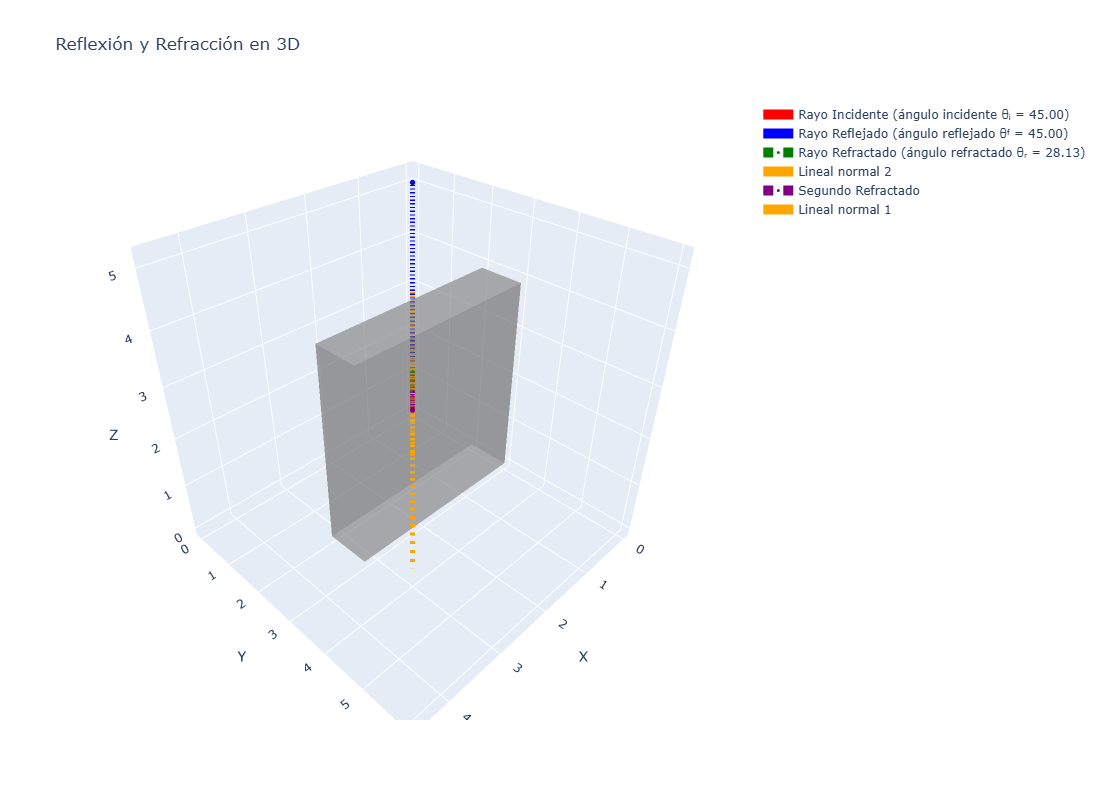

In [9]:
import numpy as np
import plotly.graph_objects as go
import math

a_and_p = int(input('Escribe "0" para ángulo de incidencia o "1" para punto de inicio'))


def reflect(I, n, calculate_angle_theta_1, hit_point, limit_x_positive, origin, LN):

    if hit_point[1]-origin[1] == 0:
        return [hit_point[0], hit_point[1], hit_point[1]]
        
    if hit_point[2]-origin[2] == 0:
         return [origin[0], origin[1], origin[2]]
        
    v_inc = [ hit_point[0]-origin[0], hit_point[1]-origin[1], hit_point[2]-origin[2] ]
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z != 0 and r_inc_x == 0:

        #module = math.sqrt((hit_point[0])**2 + (hit_point[1])**2 + (hit_point[2])**2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        theta_2 = math.degrees(angulo_radianes)
        # Distancia en y
        y = r_inc_y
        #Coordenada en z
        
        z = r_inc_y * math.sin(angulo_radianes)

        if(r_inc_y * math.sin(angulo_radianes) == LN[0][2] - origin[2] ):
            z = r_inc_y * math.sin(angulo_radianes)
        else:
            z = LN[0][2] - origin[2]
        
        return [origin[0], origin[1], LN[0][2] + z]
    if r_inc_z != 0 and r_inc_x != 0:
        angulo_radianes = math.radians(calculate_angle_theta_1)
        #Distancia en x 
        x = r_inc_x
        # Distanciaen y
        y = r_inc_y
        #hipotenusa en x and y
        hipo_xy = math.sqrt((r_inc_x**2) + (r_inc_y**2))
        
        #coordenada en z 
        f_xy =  hipo_xy/math.cos(angulo_radianes)

        if(f_xy * math.sin(angulo_radianes) == LN[0][2] - origin[2] ):
            z = f_xy * math.sin(angulo_radianes)
        else:
            z = LN[0][2] - origin[2]
        #print(x, 'x')
        #print(y, 'y')
        #print(z, 'zyes
        return [origin[0], origin[1], LN[0][2] + z]

def calculate_angle(u, v):
    

    w = [L_N[1][0]-L_N[0][0], L_N[1][1]-L_N[0][1], L_N[1][2]-L_N[0][2]]
    dot_product = np.dot(u, w)

    # Magnitudes
    norm_u = np.linalg.norm(u)
    norm_w = np.linalg.norm(w)

    # Ángulo
    
    theta_rad = math.acos(dot_product / (norm_u * norm_w))
    theta_deg = math.degrees(theta_rad)
    return theta_deg

def find_two_numbers_for_theta(theta_deg, step=0.1, limit=5, tol=0.01):
    angles_example = [
        {
            'angle': 0,
            'x': 0,
            'y': 2.5,
        },
        {
            'angle': 10,
            'x': 0,
            'y': 2.14,
        },
        {
            'angle': 20,
            'x': 0,
            'y': 1.75,
        },
        {
            'angle': 30,
            'x': 0,
            'y': 1.33,
        },
        {
            'angle': 40,
            'x': 0,
            'y': 0.81,
        },
        {
            'angle' : 50,
            'x' : 0,
            'y' : 0.1,
        },
        {
            'angle' : 50,
            'x' : 0,
            'y' : 0.1,
        },
        {
            'angle' : 60,
            'x' : 0.56,
            'y' : 0,
        },
        {
            'angle' : 70,
            'x' : 1.09,
            'y' : 0,
        },
        {
            'angle' : 80,
            'x' : 1.56,
            'y' : 0,
        },
        {
            'angle': 90,
            'x': 2,
            'y': 0,
        },
    ]
    
    resultados = []
    for x in angles_example:
        if x['angle'] == theta_deg:
            resultados.append(x)
    return resultados

def calculate_angle_theta_1(p1 , p2, LN, angle):
    
    if angle >= 0 and angle <= 90:
        #Plano ZY
        resultados = find_two_numbers_for_theta(angle)
        x = 1.5
        y = resultados[0]['x']
        z = resultados[0]['y']
        return angle, [x,y,z]
        
    if hit_point[1]-origin[1] == 0:
        return 90
    if hit_point[2]-origin[2] == 0:
        return 0
    
    v_inc = [ p2[0]-p1[0], p2[1]-p1[1], p2[2]-p1[2] ]

    r_inc_z = p2[2]-p1[2]
    r_inc_y = p2[1]-p1[1]
    r_inc_x = p2[0]-p1[0]

    #theta = calculate_angle(v_inc, LN)
    #print(theta, 'calculate_angle')

    if r_inc_z != 0 and r_inc_x == 0:

        #Plano ZY
        #f_xy = math.sqrt( ( r_inc_y )**2 + ( r_inc_z )**2 )
        #r_in_z = f_xy*cos(Theta)
        theta_radians = math.atan( r_inc_y / r_inc_z )
        theta_degress = math.degrees(theta_radians)
        theta = 180 - 90 - theta_degress
        ##print(theta, 'theta')
        #print(theta_1, 'theta 1 Entro a r_inc_z != 0 and r_inc_x == 0')
        return theta
    
    if r_inc_z != 0 and r_inc_x != 0:
        ##catetoAdyacente
        ady = LN[0][2]-p1[2]
        #catetoOpuesto
        hip_r_inc_x_y  = math.sqrt( ( r_inc_x )**2 + ( r_inc_y )**2 )
        #Angulo 
        arcotan_radians = math.atan(hip_r_inc_x_y/ady)
        arcotan_degress = math.degrees(arcotan_radians)
        #print(arcotan_degress, 'arcotan_degress')
        ## theta 1
        theta = 180 - 90 - arcotan_degress
        #print(theta, 'theta')
        #print(theta, 'theta 1 Entro r_inc_z != 0 and r_inc_x != 0')
        return theta


def linea_normal(origin, hit_point, limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, angulo_incidente):

    if angulo_incidente == 90:
        r_inc_z = 1.5
        r_inc_y = 0
        r_inc_x = 1.5
        list_point = []
        p1 = [r_inc_x, r_inc_y, r_inc_z ]
        p2 = [r_inc_x , r_inc_y + 5,  r_inc_z]
        list_point.append(p1)
        list_point.append(p2)
        return list_point
    
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]
    list_point = []
    p1 = [r_inc_x*0 + origin[0], r_inc_y*0 + origin[1], hit_point[2]]
    p2 = [r_inc_x*2 + origin[0], r_inc_y*2 + origin[1], hit_point[2]]
    #print(p1, 'p1')
    #print(p2, 'p2')
    list_point.append(p1)
    list_point.append(p2)
    return list_point
    
def refract(I, n, n1, n2, calculate_angle_theta_1, hit_point, origin, y2):
    
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z == 0:
        if r_inc_x == 0:
                return [0, y2  - hit_point[1] , 0], False, 0
        if r_inc_x != 0:
            ##(coordenada en y)
            coord_y = y2 - hit_point[1]
            ##Plano XY (coordenada en x)
            alpha = math.atan(r_inc_x/r_inc_y)
            f_xy = coord_y/math.cos(alpha)
            coord_x = f_xy * math.sin(alpha) 
            return [coord_x, y2 - hit_point[1], 0], False, 0
    if r_inc_z != 0 and r_inc_x == 0:
        #Ley de snell
        #n_1*sen(0_1) = n_2*sen(0_2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        seno_value = math.sin(angulo_radianes)
    
        rho = (n1 * seno_value)/n2
        sin_radians = math.asin(rho)
        theta_3 = math.degrees(sin_radians)
        theta_3_radians = theta_3 * (math.pi/180)
    
        coord_fx = y2 - y1
        module_f = coord_fx/(math.cos(theta_3_radians))
        fy = module_f*math.sin(theta_3_radians)
        fy_pitagoras = math.sqrt( (module_f)**2 - (coord_fx)**2)
        return [0, coord_fx, fy ], False, theta_3
    if r_inc_z != 0 and r_inc_x != 0:                
            
        #Ley de snell
        #n_1*sen(0_1) = n_2*sen(0_2)
        angulo_radianes = math.radians(calculate_angle_theta_1)
        seno_value = math.sin(angulo_radianes)
        rho = (n1 * seno_value)/n2
        sin_radians = math.asin(rho)
        theta_3 = math.degrees(sin_radians)
        theta_3_radians = theta_3 * (math.pi/180)
        
        ##(coordenada en y)
        coord_y = y2 - hit_point[1]
        ##Plano XY (coordenada en x)
        alpha = math.atan(r_inc_x/r_inc_y)
        f_xy = coord_y/math.cos(alpha)
        coord_x = f_xy * math.sin(alpha) 
        ##Plano ZX (coordenada en z)
        if (origin[0] > hit_point[0]):
            f_zx = ((-1)*coord_x)/math.cos(theta_3_radians)
        else:
            f_zx = coord_x/math.cos(theta_3_radians)
        coord_z = f_zx * math.sin(theta_3_radians)
        return [coord_x , coord_y,  coord_z  ], False, theta_3
        
def second_refract(point, n1, n2, calculate_angle_theta_1, limit_x_positive, limit_y_positive, limit_z_positive, theta_3, origin, hit_point, SLN):
    r_inc_z = hit_point[2]-origin[2]
    r_inc_y = hit_point[1]-origin[1]
    r_inc_x = hit_point[0]-origin[0]

    if r_inc_z == 0:
        if r_inc_x == 0:
            if hit_point[2]-origin[2] == 0:
                return [ [point[0], point[0]], [point[1],  SLN[1][1] ], [point[2], SLN[1][2]] ], 0
        if r_inc_x != 0:
            return [ [  point[0],  SLN[1][0] ], [point[1],  SLN[1][1] ], [point[2], SLN[1][2]] ], 0
    if r_inc_z != 0 and r_inc_x == 0:
        
        alpha = 180 - 90 - ( 90 - theta_3)
        angulo_radianes = math.radians(alpha)
        seno_value = math.sin(angulo_radianes)
        rho = (n2 * seno_value)/n1
        sin_radians = math.asin(rho)
        theta_4 = math.degrees(sin_radians)

        z = limit_z_positive * math.sin(sin_radians)
        y = limit_y_positive * math.cos(sin_radians)
        return [ [point[0], point[0]], [point[1],  point[1] + y], [point[2], point[2]+z]], theta_4
    if r_inc_z != 0 and r_inc_x != 0:
    
        w = [SLN[1][0] - point[0], SLN[1][1] - point[1], SLN[1][2] - point[2]]
        alpha_xy = math.atan(r_inc_x/r_inc_y)
        #coordenada en x
        x = w[0]
        #coordenada en y
        f_xy = x/math.sin(alpha_xy)
        y = f_xy * math.cos(alpha_xy)
        #coordenada en z
        alpha = 180 - 90 - ( 90 - theta_3)
        #print(alpha,'alpha')
        angulo_radianes = math.radians(alpha)
        seno_value = math.sin(angulo_radianes)
        rho = (n2 * seno_value)/n1
        sin_radians = math.asin(rho)
        theta_4 = math.degrees(sin_radians)
        if (origin[0] > hit_point[0]):
            f_zx =  ( (-1)*x) / math.cos(sin_radians)
        else:
            f_zx = x / math.cos(sin_radians)
        z = f_zx *  math.sin(sin_radians)
        return [ [point[0], point[0] + x], [point[1],  point[1] + y], [point[2], point[2]+z]], theta_4

plane_y = 2
thickness = 3   

limit_y_negative = 0
limit_y_positive = 5

limit_x_negative = 0
limit_x_positive = 3

limit_z_negative = 0
limit_z_positive= 5

y1 = plane_y
y2 = thickness
plane_normal = np.array([0, 0, 0]) 

n1, n2 = 1.0, 1.5

direction =  np.linalg.norm(np.array([0, 1, 1]))  # inclinación
#t = (y1 - origin[1]) / direction[1] #indificar a que plano chocara en ZX
#hit_point = origin + t * direction
hit_point = [1.5, 2, 2.5]

if a_and_p == 1:
    coord_x_p_i = float(input("Coordenada en x de [0, 3]: "))
    if coord_x_p_i >= 0.0 and coord_x_p_i <= 3.0:
        coord_y_p_i = float(input("Coordenada en y de [0, 2]: "))
        if coord_y_p_i >= 0.0 and coord_y_p_i <= 2.0:
            coord_z_p_i = float(input("Coordenada en z de [0, 2.5]: "))
            if coord_z_p_i >= 0.0 and coord_z_p_i <= 2.5:
                origin = np.array([coord_x_p_i, coord_y_p_i, coord_z_p_i])
                L_N = linea_normal(origin, hit_point,limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, 180)
                theta_1 = calculate_angle_theta_1(origin, hit_point, L_N, 180)
                figure = True
            else:
                figure = False
                print('Coordenada incorrecta en z')
        else:
            figure = False
            print('Coordenada incorrecta en y')
    else:
        figure = False
        print('Coordenada incorrecta en x')

elif a_and_p == 0:
    angle = float(input("Ángulo de [0 a 90], (solo multiplos de 10): "))
    if angle >= 0.0 and angle <= 90.0 and angle%10 == 0:
        theta_1, list_coord = calculate_angle_theta_1(origin, hit_point, L_N, angle)
        coord_x_p_i = list_coord[0]
        coord_y_p_i = list_coord[1]
        coord_z_p_i = list_coord[2]
        origin = np.array([coord_x_p_i, coord_y_p_i, coord_z_p_i])
        figure = True
    else:
        print('Ángulo incorrecto')
        figure = False
else:
    figure = False
    print('Vuelvelo a intentar')

L_N = linea_normal(origin, hit_point,limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, theta_1)

z_max = 0
x_max = 0
if theta_1 != 90:
    #print(theta_1,'theta_1')
    R = reflect(direction, plane_normal, calculate_angle_theta_1(origin, hit_point, L_N, 180), hit_point, limit_x_positive, origin, L_N)
    #print(R, 'R')
    #print(theta_1, 'theta_1')
    T, tir, theta_3 = refract(direction, plane_normal, n1, n2, calculate_angle_theta_1(origin, hit_point, L_N, 180), hit_point, origin, y2)
    z_max = hit_point[2] + T[2]
    x_max = hit_point[0] + T[0]
    #print(theta_3, 'theta_3')
    SLN = linea_normal(origin, np.array([hit_point[0] + T[0], hit_point[1] + T[1], hit_point[2] + T[2]]),limit_y_negative, limit_y_positive, limit_x_negative, limit_x_positive, thickness, theta_1)
    ST, theta_4 = second_refract([ hit_point[0] + T[0], hit_point[1] + T[1], hit_point[2] + T[2]], n1, n2, calculate_angle_theta_1(origin, hit_point, L_N, 180), limit_x_positive, limit_y_positive, limit_z_positive, theta_3, origin, hit_point, SLN)
    #print(theta_4, 'theta_4



if figure:
    
    fig = go.Figure()
    
    ## -----------Planos ZX--------------
    xx_xz, zz_xz = np.meshgrid(np.linspace(0, x_max + 1, 10), np.linspace(0, z_max + 1, 10))
    yy_xz_1 = np.ones_like(xx_xz) * y1
    yy_xz_2 = np.ones_like(xx_xz) * y2
    
    fig.add_trace(go.Surface(x=xx_xz, y=yy_xz_1, z=zz_xz, colorscale=[[0,'gray'],[1,'gray']],opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_xz, y=yy_xz_2, z=zz_xz,colorscale=[[0,'gray'],[1,'gray']],opacity=0.4, showscale=False))
    
    ##-------------Planos ZY--------------
    zz_zy, yy_zy = np.meshgrid(np.linspace(0, z_max + 1, 10), np.linspace(2, 3 , 10))
    xx_zy_1 = np.ones_like(zz_zy) * 0
    xx_zy_2 = np.ones_like(zz_zy) * x_max + 1
    
    fig.add_trace(go.Surface(x=xx_zy_1, y=yy_zy, z=zz_zy, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_zy_2, y=yy_zy, z=zz_zy, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    
    ##-------------Planos XY------------
    xx_xy, yy_xy = np.meshgrid(np.linspace(0, x_max + 1, 10), np.linspace(2, 3,10))
    zz_xy_1= np.ones_like(xx_xy) * 0
    zz_xy_2= np.ones_like(xx_xy) * z_max + 1
    
    fig.add_trace(go.Surface(x=xx_xy, y=yy_xy, z=zz_xy_1, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    fig.add_trace(go.Surface(x=xx_xy, y=yy_xy, z=zz_xy_2, colorscale=[[0, 'gray'],[1,'gray']], opacity=0.4, showscale=False))
    
    width = 10
    ## Rayos Trazados
    
    if theta_1 == 90:
        fig.add_trace(go.Scatter3d(
            x=[origin[0], hit_point[0]],
            y=[origin[1], hit_point[1]],
            z=[origin[2], hit_point[2] + 2.5],
            mode='lines+markers',
            line=dict(color='red', width=width),
            marker=dict(size=3, color='red'),
            name=fr"Rayo Incidente (ángulo incidente θᵢ = {theta_1:.2f})"
        ))
    else:
        fig.add_trace(go.Scatter3d(
                x=[origin[0], hit_point[0]],
                y=[origin[1], hit_point[1]],
                z=[origin[2], hit_point[2]],
                mode='lines+markers',
                line=dict(color='red', width=width),
                marker=dict(size=3, color='red'),
                name=fr"Rayo Incidente (ángulo incidente θᵢ = {theta_1:.2f})"
            ),
        )
    if theta_1 != 90:
        fig.add_trace(go.Scatter3d(
            x=[hit_point[0], (R[0])],
            y=[hit_point[1], (R[1])],
            z=[hit_point[2], (R[2])],
            mode='lines+markers',
            line=dict(color='blue', width=width, dash="dash"),
            marker=dict(size=3, color='blue'),
            name=fr"Rayo Reflejado (ángulo reflejado θᶠ = {theta_1:.2f})"
        ))
        fig.add_trace(go.Scatter3d(
            x=[hit_point[0], hit_point[0] + T[0]],
            y=[hit_point[1], hit_point[1] + T[1]],
            z=[hit_point[2], hit_point[2] + T[2]],
            mode='lines+markers',
            line=dict(color='green', width=width, dash="dot"),
            marker=dict(size=3, color='green'),
            name=fr"Rayo Refractado (ángulo refractado θᵣ = {theta_3:.2f})"
        ))
        fig.add_trace(go.Scatter3d(
            x=[SLN[0][0], SLN[1][0]],
            y=[SLN[0][1], SLN[1][1]],
            z=[SLN[0][2], SLN[1][2]],
            mode='lines',
            line=dict(color='orange', width=width, dash="dash"),
            marker=dict(size=3, color='orange'),
            name='Lineal normal 2'
        ))
        fig.add_trace(go.Scatter3d(
            x=[ST[0][0], ST[0][1] ],
            y=[ST[1][0], ST[1][1]],
            z=[ST[2][0], ST[2][1]],
            mode='lines+markers',
            line=dict(color='purple', width=width, dash="dot"),
            marker=dict(size=3, color='purple'),
            name='Segundo Refractado'
        ))
    fig.add_trace(go.Scatter3d(
        x=[L_N[0][0], L_N[1][0]],
        y=[L_N[0][1], L_N[1][1]],
        z=[L_N[0][2], L_N[1][2]],
        mode='lines',
        line=dict(color='orange', width=width, dash="dash"),
        marker=dict(size=3, color='orange'),
        name='Lineal normal 1'
    ))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X'),
            yaxis=dict(title='Y'),
            zaxis=dict(title='Z'),
            aspectmode="cube"
        ),
        width=800,
        height=800,
        title="Reflexión y Refracción en 3D"
    )
    fig.show()